In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Load the same dataset
df = pd.read_csv("../data/Sample - Superstore.csv",
                 parse_dates=["Order Date", "Ship Date"],
                 encoding="latin-1")

# Select features that represent the financial fingerprint of each transaction
# These four columns together describe what happened in each order financially
features = ["Sales", "Quantity", "Discount", "Profit"]

# Create a clean feature matrix with no missing values
X = df[features].copy()

print("Feature matrix shape:", X.shape)
print("\nSample of feature matrix:")
print(X.head())

print("\nAny missing values:", X.isnull().sum().sum())

Feature matrix shape: (9994, 4)

Sample of feature matrix:
      Sales  Quantity  Discount    Profit
0  261.9600         2      0.00   41.9136
1  731.9400         3      0.00  219.5820
2   14.6200         2      0.00    6.8714
3  957.5775         5      0.45 -383.0310
4   22.3680         2      0.20    2.5164

Any missing values: 0


In [2]:
# Scale all four features to the same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# contamination is our estimate of what fraction of rows are anomalies
# 0.01 means we expect roughly 1% of transactions to be anomalous
# random_state ensures reproducibility like in your crop project
iso_forest = IsolationForest(contamination=0.01,
                             random_state=42,
                             n_estimators=100)

iso_forest.fit(X_scaled)

# Get predictions — Isolation Forest returns:
# -1 for anomalies
#  1 for normal points
df["Anomaly"] = iso_forest.predict(X_scaled)

# Get the raw anomaly score for each row
# More negative score = more anomalous
df["Anomaly_Score"] = iso_forest.decision_function(X_scaled)

# Check how many anomalies were detected
print("Anomaly counts:")
print(df["Anomaly"].value_counts())

print("\nSample anomaly scores:")
print(df[["Sales", "Quantity", "Discount", "Profit",
          "Anomaly", "Anomaly_Score"]].head(10))

Anomaly counts:
Anomaly
 1    9894
-1     100
Name: count, dtype: int64

Sample anomaly scores:
      Sales  Quantity  Discount    Profit  Anomaly  Anomaly_Score
0  261.9600         2      0.00   41.9136        1       0.286626
1  731.9400         3      0.00  219.5820        1       0.192049
2   14.6200         2      0.00    6.8714        1       0.331383
3  957.5775         5      0.45 -383.0310        1       0.070278
4   22.3680         2      0.20    2.5164        1       0.336344
5   48.8600         7      0.00   14.1694        1       0.283361
6    7.2800         4      0.00    1.9656        1       0.310734
7  907.1520         6      0.20   90.7152        1       0.199780
8   18.5040         3      0.20    5.7825        1       0.339095
9  114.9000         5      0.00   34.4700        1       0.297250


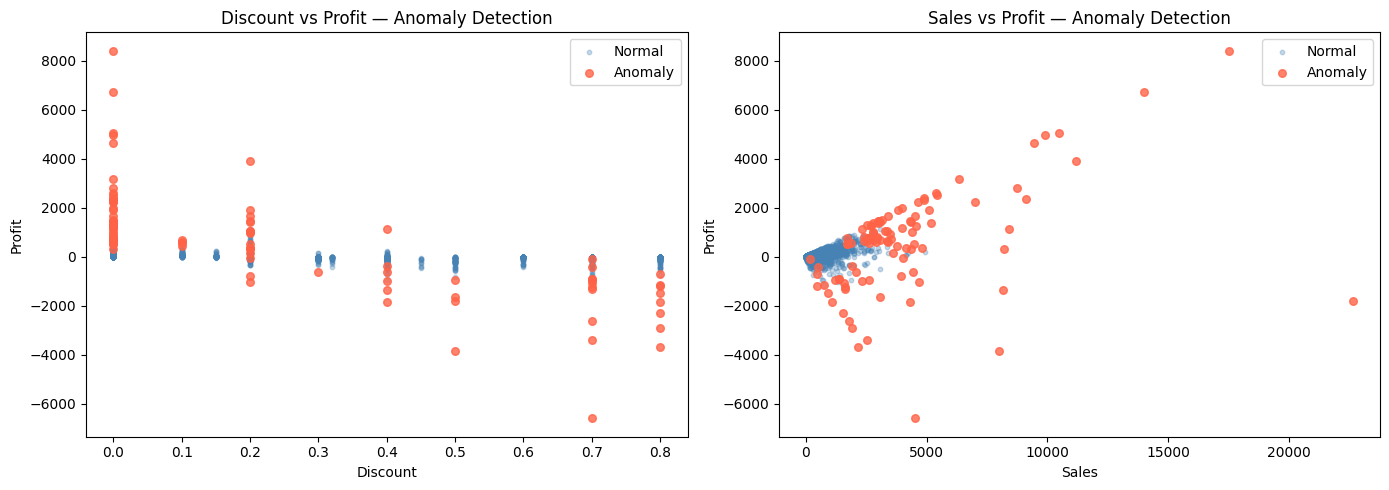

In [4]:
# Visualise anomalies vs normal transactions across two key dimensions
# We use Discount vs Profit because your observation showed that relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Discount vs Profit, coloured by anomaly label
normal = df[df["Anomaly"] == 1]
anomaly = df[df["Anomaly"] == -1]

axes[0].scatter(normal["Discount"], normal["Profit"],
                color="steelblue", alpha=0.3, s=10, label="Normal")
axes[0].scatter(anomaly["Discount"], anomaly["Profit"],
                color="tomato", alpha=0.8, s=30, label="Anomaly")
axes[0].set_title("Discount vs Profit — Anomaly Detection")
axes[0].set_xlabel("Discount")
axes[0].set_ylabel("Profit")
axes[0].legend()

# Plot 2 — Sales vs Profit, coloured by anomaly label
axes[1].scatter(normal["Sales"], normal["Profit"],
                color="steelblue", alpha=0.3, s=10, label="Normal")
axes[1].scatter(anomaly["Sales"], anomaly["Profit"],
                color="tomato", alpha=0.8, s=30, label="Anomaly")
axes[1].set_title("Sales vs Profit — Anomaly Detection")
axes[1].set_xlabel("Sales")
axes[1].set_ylabel("Profit")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Which categories contain the most anomalies
print("Anomalies by Category:")
print(anomalies["Category"].value_counts())

print("\nAnomalies by Region:")
print(anomalies["Region"].value_counts())

print("\nAnomalies by Sub-Category:")
print(anomalies["Sub-Category"].value_counts().head(10))

# Compare average financials of anomalies vs normal transactions
print("\nFinancial comparison — Normal vs Anomaly:")
comparison = df.groupby("Anomaly")[["Sales",
                                    "Quantity",
                                    "Discount",
                                    "Profit"]].mean().round(2)
# Rename index for readability
comparison.index = ["Anomaly", "Normal"]
print(comparison)

Anomalies by Category:
Category
Technology         46
Office Supplies    38
Furniture          16
Name: count, dtype: int64

Anomalies by Region:
Region
East       40
Central    21
South      21
West       18
Name: count, dtype: int64

Anomalies by Sub-Category:
Sub-Category
Binders        28
Machines       25
Copiers        12
Chairs          8
Phones          8
Appliances      6
Tables          5
Bookcases       3
Supplies        3
Accessories     1
Name: count, dtype: int64

Financial comparison — Normal vs Anomaly:
           Sales  Quantity  Discount  Profit
Anomaly  4117.34      6.62      0.23  568.92
Normal    190.57      3.76      0.16   23.20


In [6]:
# Separate anomalies into two meaningful business categories
# Positive anomalies -- unusually high profit, potential best practices
# Negative anomalies -- unusually low or negative profit, potential risk

anomalies_positive = anomalies[anomalies["Profit"] > 0].copy()
anomalies_negative = anomalies[anomalies["Profit"] <= 0].copy()

print(f"Positive anomalies (high profit outliers): {len(anomalies_positive)}")
print(f"Negative anomalies (loss or risk outliers): {len(anomalies_negative)}")

print("\nPositive anomaly profile (avg):")
print(anomalies_positive[["Sales", "Quantity",
                           "Discount", "Profit"]].mean().round(2))

print("\nNegative anomaly profile (avg):")
print(anomalies_negative[["Sales", "Quantity",
                           "Discount", "Profit"]].mean().round(2))

# Tag them clearly in the dataframe
df["Anomaly_Type"] = "Normal"
df.loc[anomalies_positive.index, "Anomaly_Type"] = "Opportunity"
df.loc[anomalies_negative.index, "Anomaly_Type"] = "Risk"

print("\nAnomaly type distribution:")
print(df["Anomaly_Type"].value_counts())

Positive anomalies (high profit outliers): 68
Negative anomalies (loss or risk outliers): 32

Positive anomaly profile (avg):
Sales       4589.66
Quantity       6.51
Discount       0.05
Profit      1584.50
dtype: float64

Negative anomaly profile (avg):
Sales       3113.66
Quantity       6.84
Discount       0.59
Profit     -1589.19
dtype: float64

Anomaly type distribution:
Anomaly_Type
Normal         9894
Opportunity      68
Risk             32
Name: count, dtype: int64
